# This script tests different algorithms' ability to predict financial trends.
The plan is to use multiple statistical and machine learning models on S&P 500 data to predict crashes and bubbles.

- Download historical S&P500 data from Kaggle.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import kaggle

kaggle.api.authenticate()

kaggle_path = "andrewmvd/sp-500-stocks"
local_path = "./Kaggle_data/"

if not os.path.exists(local_path) or not os.listdir(local_path):
    print(f"Downloading files to {local_path}...")
    kaggle.api.dataset_download_files(kaggle_path, path=local_path, unzip=True)
    print("Download complete.")
else:
    print(f"Files found in {local_path}. Skipping download.")

Files found in ./Kaggle_data/. Skipping download.


- Define a plotting function to visualize the data.
- Written for testing, the following cell can be ignored.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_sp500_index(csv_path):

    if not os.path.exists(csv_path):
        print(f"Error: File not found at {csv_path}")
        return

    try:
        df = pd.read_csv(csv_path)
        print(f"Loaded data from {csv_path}. Shape: {df.shape}")
        
        if 'Date' not in df.columns or 'S&P500' not in df.columns:
             print("Error: CSV does not contain required columns 'Date' and 'S&P500'")
             # print columns to help debug
             print(f"Columns found: {df.columns}")
             return
             
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date')
        
        # plt.figure(figsize=(12, 6))
        plt.plot(df['Date'], df['S&P500'], label='S&P 500 Index')
        plt.xlabel('Date')
        plt.ylabel('S&P 500 Value')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"An error occurred: {e}")

# plot_sp500_index(local_path + "sp500_index.csv")

- Implement different models on the S&P 500 data to forecast the last 500 datapoints/days.
- Load file and define plotting and directional accuracy calculation function to be called after the forecast.

In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

csv_path = local_path + "sp500_index.csv"
forecast_days = 500

def read_file(csv_path):
    """Reads csv file and returns a DataFrame with time and stock price.
    """
    if not os.path.exists(csv_path):
        print(f"Error: File not found at {csv_path}.")
        return

    df = pd.read_csv(csv_path)
    print(f"Loaded data from {csv_path}. Shape: {df.shape}")

    if 'Date' not in df.columns or 'S&P500' not in df.columns:
        print("Error: CSV does not contain required columns 'Date' and 'S&P500'")
        # print columns to help debug
        print(f"Columns found: {df.columns}")
        return
            
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    return df


def plot_forecast(df, forecast_df):
    """
    Plots the original price vs HMM predicted price along with the uncertainty bounds,
    including a residual plot at the bottom.
    """
    sns.set_style("whitegrid")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # Plot Original Data
    ax1.plot(df['Date'], df['S&P500'], 
             label='Actual Price', color='#2c3e50', alpha=0.8, lw=1.5)
    
    # Plot Forecasted Data
    ax1.plot(forecast_df['Date'], forecast_df['S&P500_forecast'], 
             label='HMM Forecast', color='#e67e22', lw=2, linestyle='--')
    
    # Add Shaded Lower and Upper Bounds
    ax1.fill_between(forecast_df['Date'], forecast_df['S&P500_lower_bound'],
                     forecast_df['S&P500_upper_bound'], 
                     color="#f5a930", alpha=0.3, label=r'1$\sigma$ Uncertainty')
    
    ax1.set_title('S&P 500 Forecast', fontsize=16)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.legend(loc='upper left')

    
    actual_test_prices = df.iloc[-len(forecast_df):]['S&P500'].values
    residuals = actual_test_prices - forecast_df['S&P500_forecast'].values
    
    ax2.scatter(forecast_df['Date'], residuals, color='#c0392b', s=10, alpha=0.5)
    ax2.axhline(0, color='black', lw=1, linestyle='-')
    ax2.set_title('Residuals', fontsize=14)
    ax2.set_ylabel('Error ($)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)

    plt.tight_layout()
    plt.show()


df = read_file(csv_path)

Loaded data from ./Kaggle_data/sp500_index.csv. Shape: (2517, 2)


- I am defining accuracy as being able to predict the positvie or negative movement of price in a given window of days (a month for example, 22 trading days per month).

In [4]:
def directional_accuracy(price, forecast_price, window=22):
    if len(forecast_price) < window:
        print("Directional accuracy can not be calculated.")
        print(f"Forecast size ({len(forecast_price)}) < Window size ({window})")
        return 0.
    num_accurate = 0
    num_windows = len(forecast_price) // window

    residual = sum(price - forecast_price)
    print(f"Net residual = {residual}")
    
    for i in range(num_windows):
        real_direction = 1 if price[i + window] > price[i] else 0
        forecast_direction = 1 if forecast_price[i + window] > forecast_price[i] else 0
        if real_direction == forecast_direction:
            num_accurate += 1
    
    accuracy = (num_accurate / num_windows) * 100
    
    return accuracy


## The Hidden Markov Model (HMM)
- Implement the HMM model and calculate its directional accuracy.

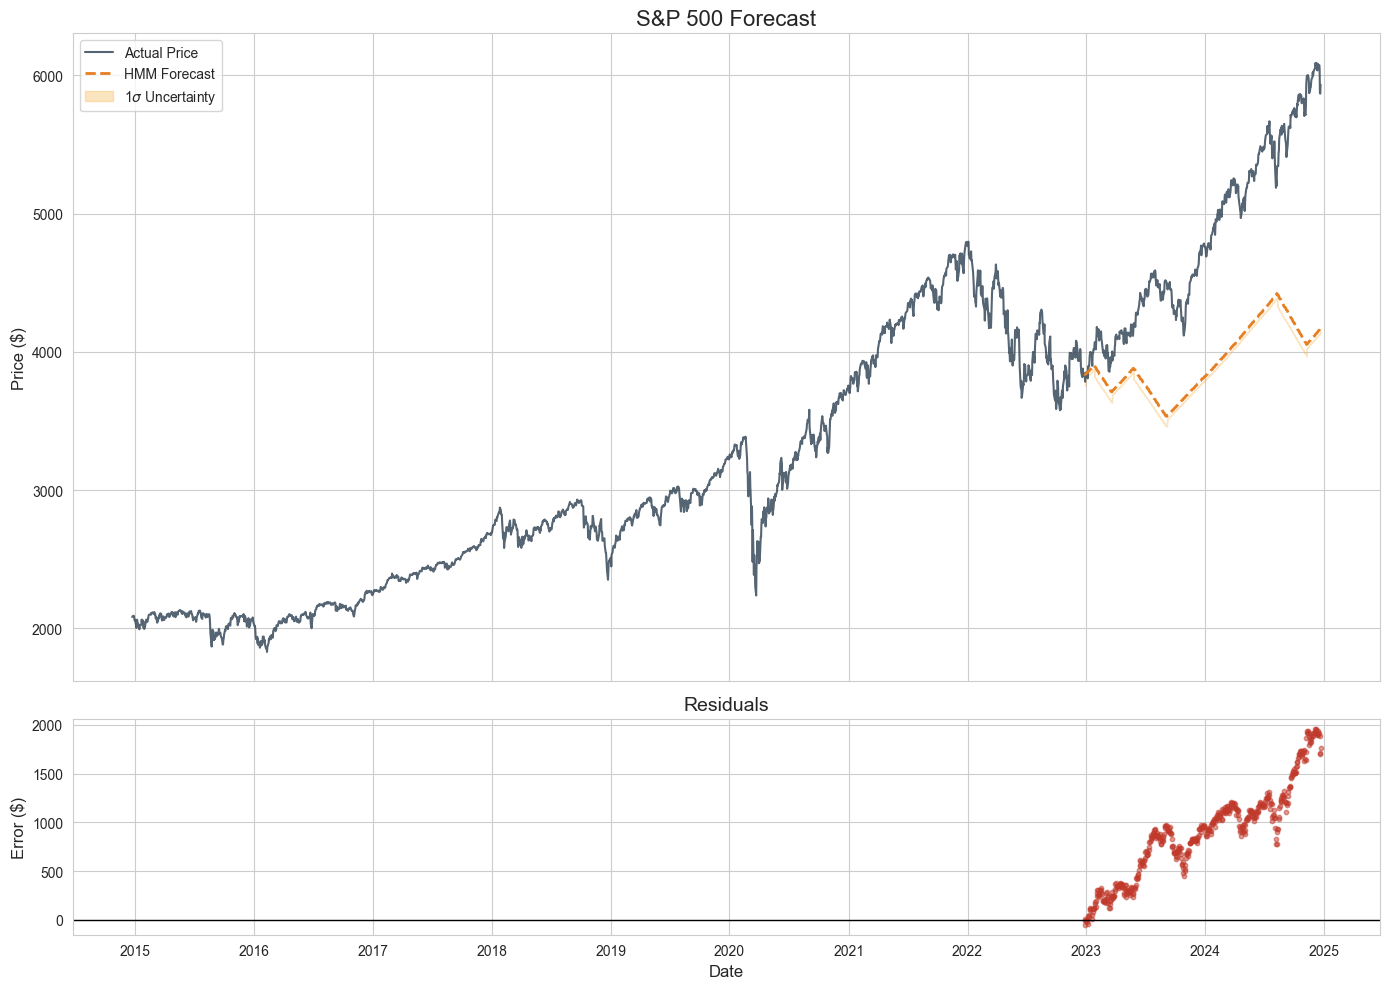

Net residual = 448989.4381695588
HMM directional accuracy: 54.55%


In [58]:
from hmmlearn.hmm import GaussianHMM


def model_predict_hmm(df, nstates=2, forecast=forecast_days):
    """Models and predicts future stock values.
    df (DataFrame): df containing dates and stock values.
    nstates (int): number of hidden states to model.
    forecast (int): number of steps to forecast.

    Returns forecast_df (DataFrame): df containing dates, predicted_values, lower_bound, upper_bound
    """
    df['Log_Returns'] = np.log(df['S&P500'] / df['S&P500'].shift(1))
    df.dropna(inplace=True)

    # Split data for training and testing
    train_df = df.iloc[:-forecast].copy()
    test_df = df.iloc[-forecast:].copy()

    # GaussianHMM modeling
    seed = 123456  # random_state seed for reproducibility
    model = GaussianHMM(n_components=nstates, covariance_type="diag", n_iter=1000, random_state=seed)

    X_train = train_df['Log_Returns'].values.reshape(-1, 1)  # Reshape for hmmlearn; array[samples, features]
    model.fit(X_train)

    # Predict
    current_state = model.predict(X_train)[-1]

    forecast_log_returns = []
    uncertainties = []

    last_state = current_state
    for _ in range(forecast):
        probs = model.transmat_[last_state]
        next_state = np.random.choice(len(probs), p=probs)

        mean = model.means_[next_state][0]
        var = np.diag(model.covars_[next_state])[0]

        forecast_log_returns.append(mean)
        uncertainties.append(np.sqrt(var))  # Uncertainty = Standard deviation
        last_state = next_state
    
    # Convert to price
    last_price = train_df['S&P500'].iloc[-1]
    forecast_prices = last_price * np.exp(np.cumsum(forecast_log_returns))
    forecast_uncertainties = forecast_prices * np.array(uncertainties)
    forecast_lower_bound = forecast_prices - forecast_uncertainties
    forecast_upper_bound = forecast_prices - forecast_uncertainties

    forecast_df = pd.DataFrame({
        'Date': test_df['Date'].values,
        'S&P500_forecast': forecast_prices,
        'S&P500_lower_bound': forecast_lower_bound,
        'S&P500_upper_bound': forecast_upper_bound
    })

    return forecast_df



forecast_df = model_predict_hmm(df)
plot_forecast(df, forecast_df)
original_price = np.array(df['S&P500'][-len(forecast_df):])
hmm_forecast_price = np.array(forecast_df['S&P500_forecast'])
hmm_dir_accuracy = directional_accuracy(original_price, hmm_forecast_price)
print(f"HMM directional accuracy: {hmm_dir_accuracy:.2f}%")

### Cons of the Hidden Markov Model (HMM):
- The model assumes the future depends only on the current state. It lacks a memory of long-term trends, which is likely to be the reason for high error as seen in the residual plot.
- The reality of market drift is ignored in this model.
### ARIMA as an alternative to HMM:
- ARIMA stands for AutoRegressive Integrated Moving Average. This model attempts to model the movement of the price by looking at its trend and noise. 
- In ARIMA ($p$, $d$, $q$), the AutoRegressive (AR - $p$) part of ARIMA takes the relationship between a datapoint and a number of lagged data into account. If $p=1$, the current price is a function of yesterday's price plus some noise. The Integrated (I - $d$) part differenciates the raw observations to make the time series stationary. A value of $d=1$ equates to modeling the change in price rather than the price itself. And the Moving Average (MA - $q$) component models the relationship between a data and a residual error from a moving average model applied to lagged observations.

## The ARIMA model
- Implement and compare the performance with HMM.

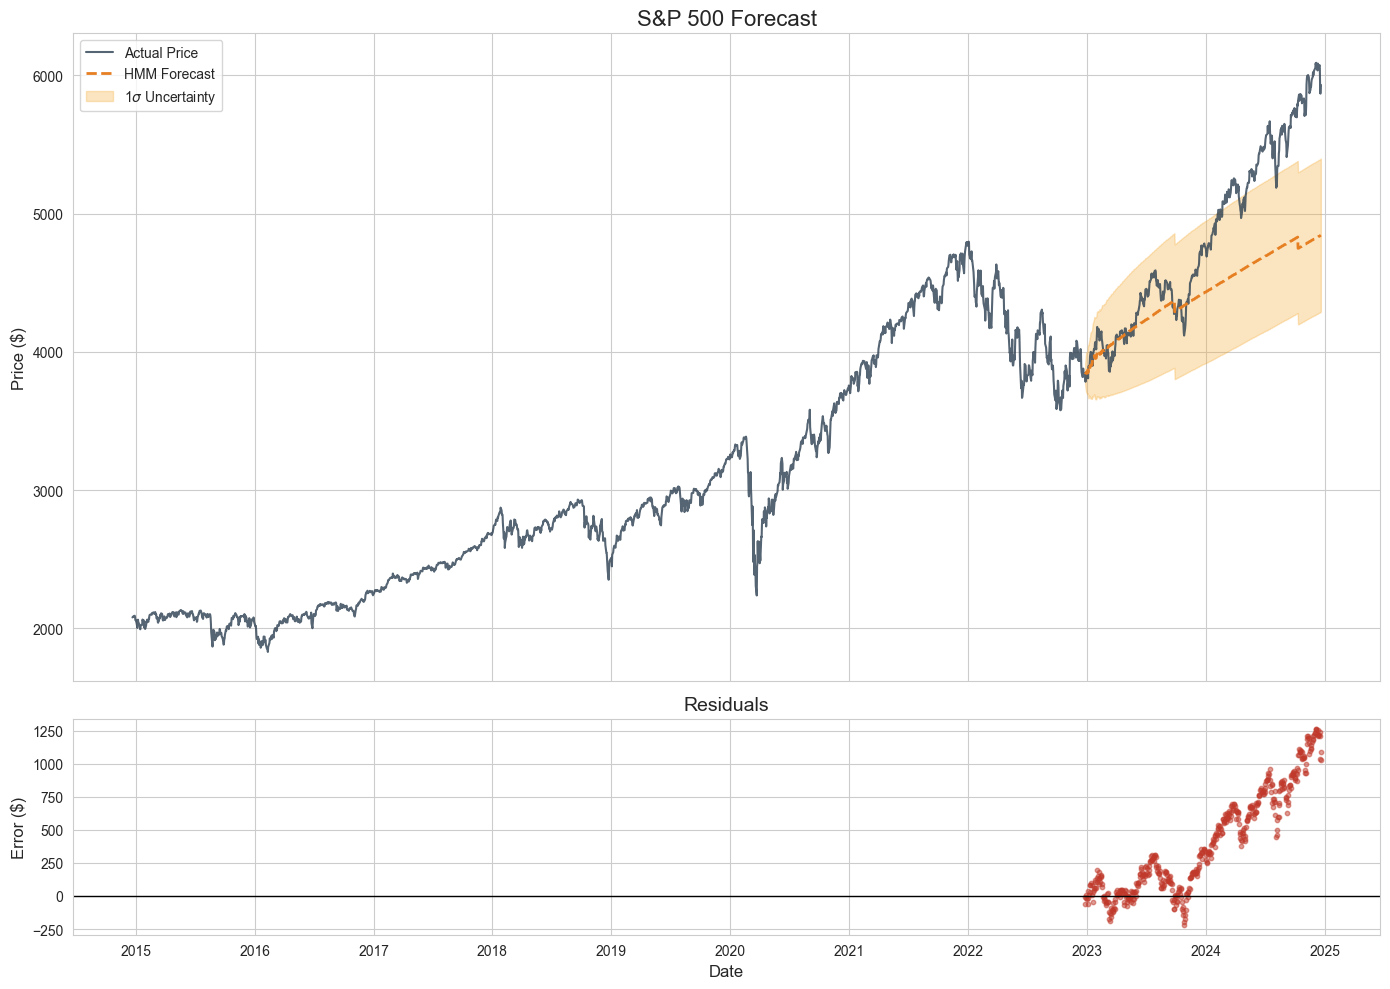

Net residual = 204000.956850762
ARIMA directional accuracy: 77.27%


In [14]:
from statsmodels.tsa.arima.model import ARIMA

def model_predict_arima(df, forecast=forecast_days):
    """Models and predicts future stock values.
    df (DataFrame): df containing dates and stock values.
    forecast (int): number of steps to forecast.

    Returns forecast_df (DataFrame): df containing dates, predicted_values, lower_bound, upper_bound
    """
    # Split data for training and testing
    train_df = df.iloc[:-forecast].copy()
    test_df = df.iloc[-forecast:].copy()

    # Fit the ARIMA model
    model = ARIMA(train_df['S&P500'], order=(22, 0, 50), trend=[1,1,0,1])
    model_fit = model.fit()

    forecast_obj = model_fit.get_forecast(steps=forecast)
    forecast_prices = forecast_obj.predicted_mean
    confidence_intervals = forecast_obj.conf_int()
    
    
    forecast_df = pd.DataFrame({
        'Date': test_df['Date'].values,
        'S&P500_forecast': forecast_prices,
        'S&P500_lower_bound': confidence_intervals['lower S&P500'],
        'S&P500_upper_bound': confidence_intervals['upper S&P500']
    })

    return forecast_df


forecast_df = model_predict_arima(df)
plot_forecast(df, forecast_df)

original_price = np.array(df['S&P500'][-len(forecast_df):])
arima_forecast_price = np.array(forecast_df['S&P500_forecast'])
arima_dir_accuracy = directional_accuracy(original_price, arima_forecast_price)
print(f"ARIMA directional accuracy: {arima_dir_accuracy:.2f}%")

- ARIMA outperforms the HMM in both net residuals and directional accuracy.

### Cons of the ARIMA Model:
- Even though the model has a memory of long-term trends, and performs better than HMM, it lacks the ability to handle the noise or chaos of financial data.
- It can not capture non-linear relationships in the data.
### XGBoost as an alternative to ARIMA and HMM:
- We can feed multiple features in XGBoost to predict the movement of price at each instance.
## The XGBoost model
- Implement and compare the performance with ARIMA and HMM. ...